# Paper plots — KL-diag protagonist (Polar-LoRA)

Locked config: `kl-diag-polar-lora` · PolarExpress PE=8 · Nesterov · β₁=0.9 · δ=1e-4 · k=1 · curvature_beta=0.99 · precond_refresh_every=10 · **precond_method=gram_ns**. AdamW + iMuon baselines; σ=0.0017 noise floor.

In-flight runs render partially (`allow_partial=True`).

In [1]:
%load_ext autoreload
%autoreload 2

# Every definition -- arm predicates, the per-cell run cache, the panel functions --
# lives in lora_playground/plotting/paper_plots_lib.py, NOT in these cells. Reach
# through P (P.PROTO, P.rr_slot_panel, ...): with autoreload on, an edit to that file
# is picked up on the next cell you run, with no "which cell defines this again?".
# Definitions used to sit in cells 1/33/35/47, which is why a fix on disk could sit
# there while the notebook kept raising the error it fixed.
import lora_playground.plotting.paper_plots_lib as P

# Legacy aliases for Figures 17-20, whose cells still carry their own plotting code and
# have not been moved into the module yet. Names bound HERE do not track edits to the
# module -- that is the staleness this restructure removes -- so use P.<name> in any new
# cell, and treat this block as temporary.
from lora_playground.plotting.paper_plots_lib import (
    ROOT, SIGMA, ADAMW, PROTO, cell_runs,
    om as _om, pred_matches as _pred_matches, variant_key_fn as _variant_key_fn,
)
from lora_playground.plotting import compare_variants_figure


## Per-cell panels — AdamW vs Polar-LoRA (kl-diag) vs iMuon vs naive factor-Muon vs the double-ablation (w/o curvature+magnitude); baseline arms render in any panel where their runs exist (in-flight runs show from first eval)

### Figure 1. OLMo-2-1B opc r256

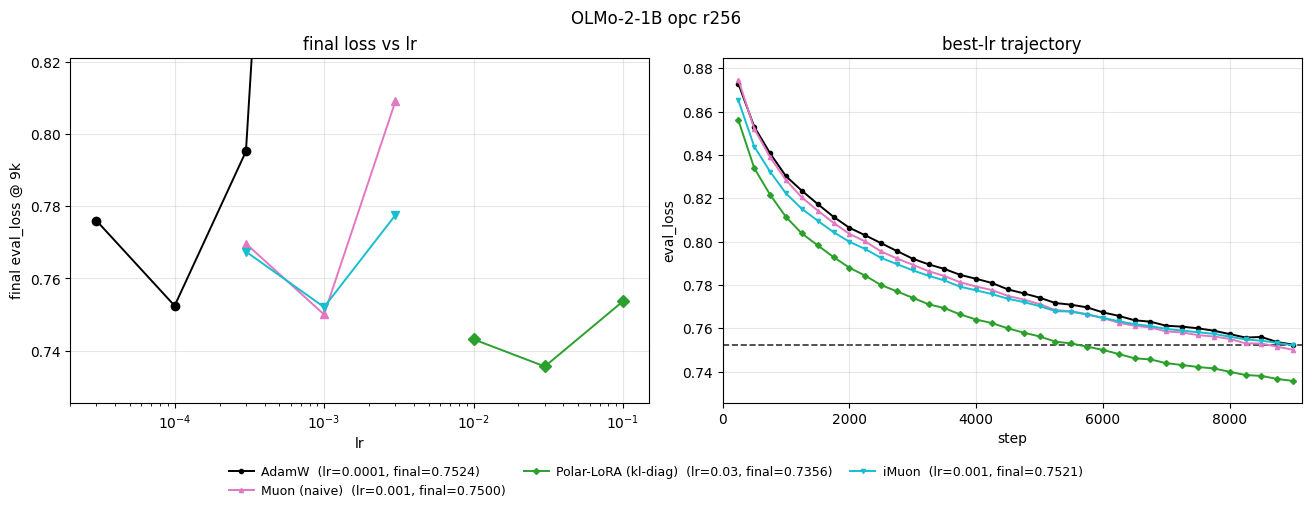

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,NaN,NaN
1,Muon (naive),0.0010,0.750033,-0.002406,-1.415284
2,Polar-LoRA (kl-diag),0.0300,0.735641,-0.016797,-9.880739
3,iMuon,0.0010,0.752073,-0.000365,-0.214891


In [2]:
P.panel_n(0)   # OLMo-2-1B opc r256


### Figure 2. Qwen2.5-1.5B opc r256

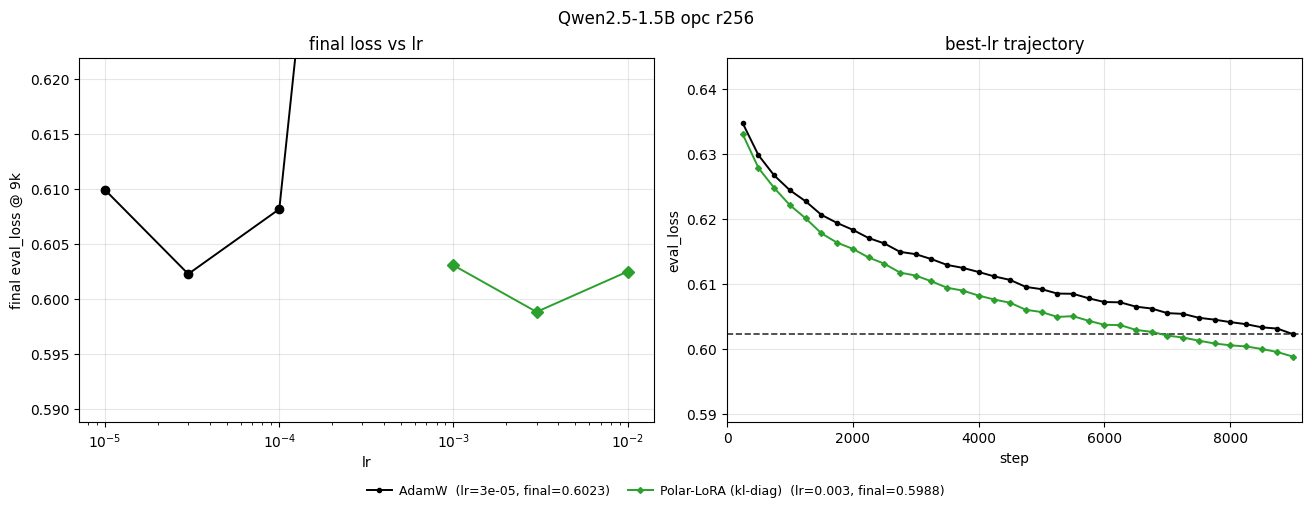

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.602292,NaN,NaN
1,Polar-LoRA (kl-diag),0.00300,0.598845,-0.003447,-2.027497


In [3]:
P.panel_n(1)   # Qwen2.5-1.5B opc r256


### Figure 3. Llama-3.2-1B opc r256

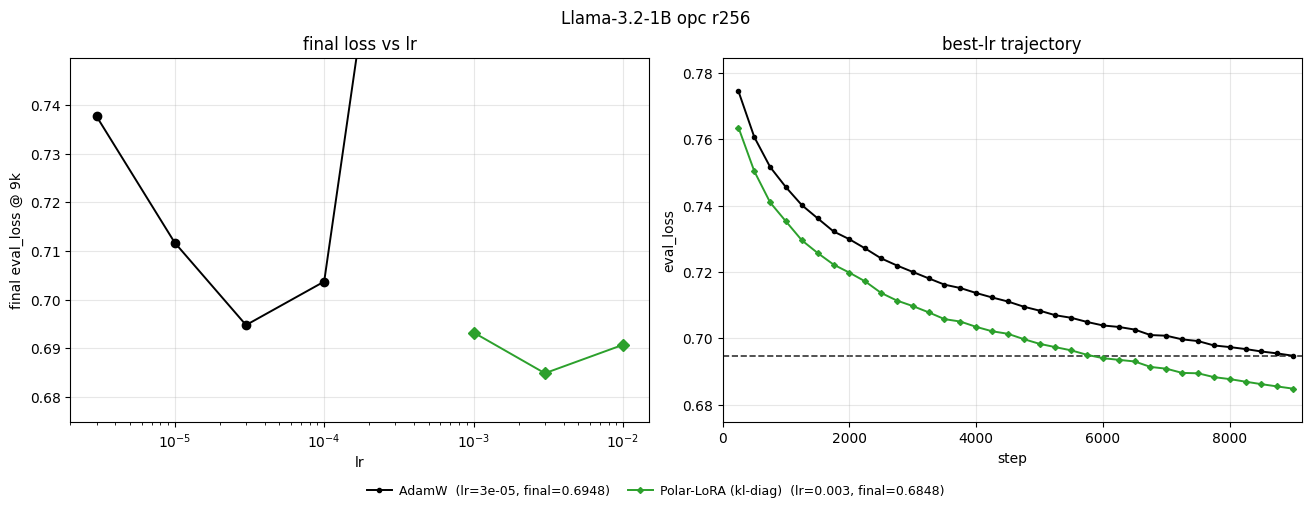

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.694754,NaN,NaN
1,Polar-LoRA (kl-diag),0.00300,0.684849,-0.009905,-5.826258


In [4]:
P.panel_n(2)   # Llama-3.2-1B opc r256


### Figure 4. Llama-3-8B opc r256

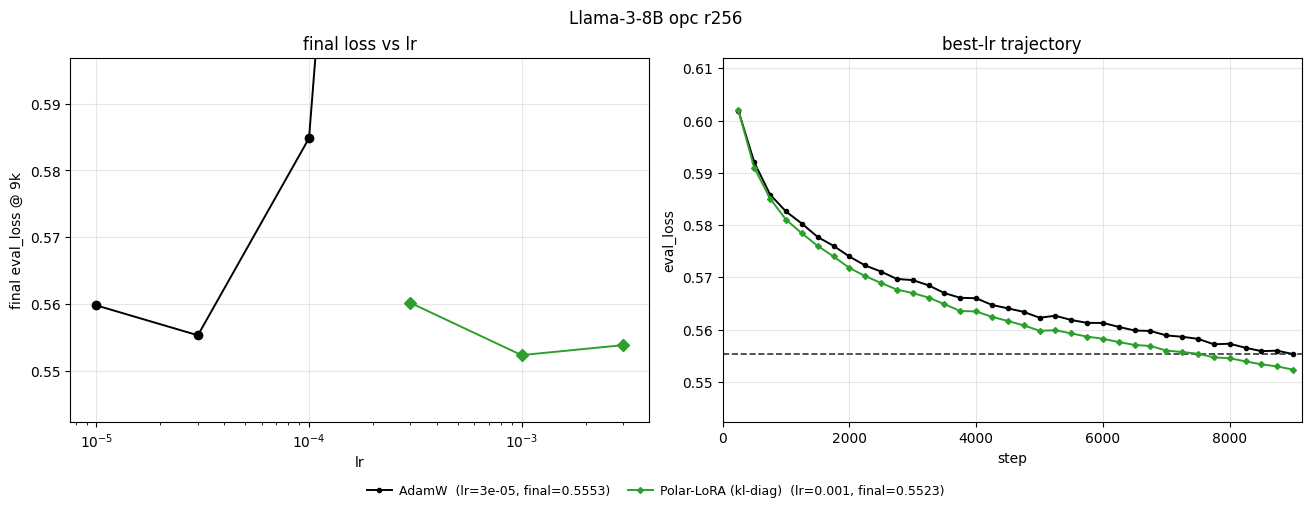

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.555303,NaN,NaN
1,Polar-LoRA (kl-diag),0.00100,0.552333,-0.00297,-1.747025


In [5]:
P.panel_n(3)   # Llama-3-8B opc r256


### Figure 5. Qwen2.5-1.5B bengali r256  (OOD pair vs cell 2)

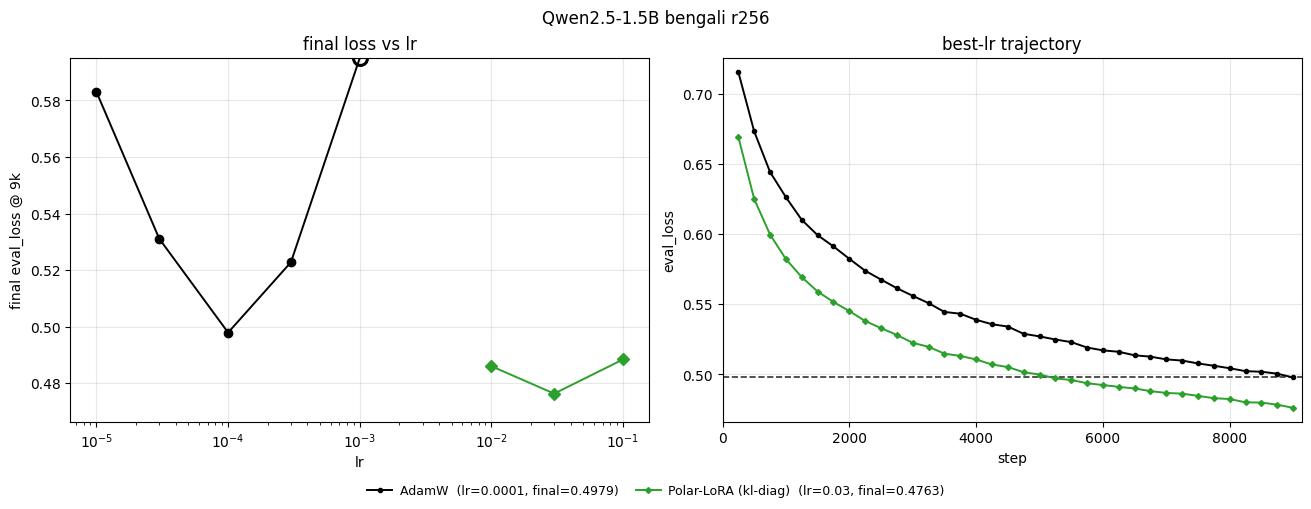

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.497858,NaN,NaN
1,Polar-LoRA (kl-diag),0.0300,0.476251,-0.021607,-12.710198


In [6]:
P.panel_n(4)   # Qwen2.5-1.5B bengali r256


## Math model breadth — openmath r256

Parallel to the opc breadth panels above: only the base model varies, rank fixed at $r=256$, finetuning corpus is OpenMathInstruct-2. Llama-3.2-1B openmath r256 is the rank-ladder top cell below. Each panel: AdamW vs Polar-LoRA (kl-diag); iMuon/Muon arms render only where their runs exist (`allow_partial`).

### Figure 6. OLMo-2-1B openmath r256  (math breadth)

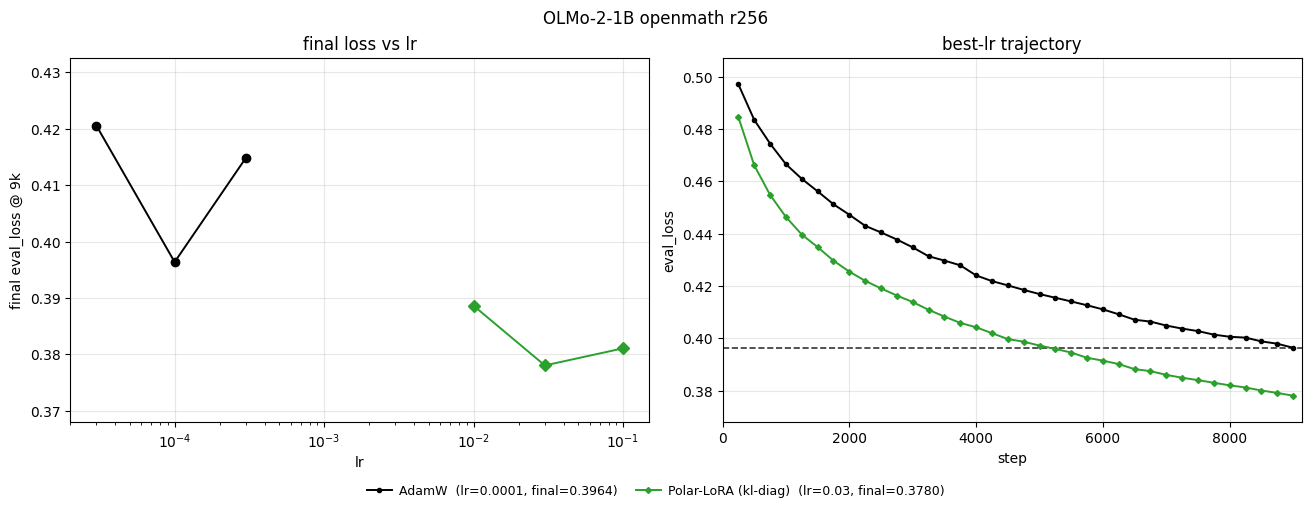

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.396363,NaN,NaN
1,Polar-LoRA (kl-diag),0.0300,0.378044,-0.01832,-10.77627


In [7]:
P.panel_n(5)   # OLMo-2-1B openmath r256


### Figure 7. Qwen2.5-1.5B openmath r256  (math breadth)

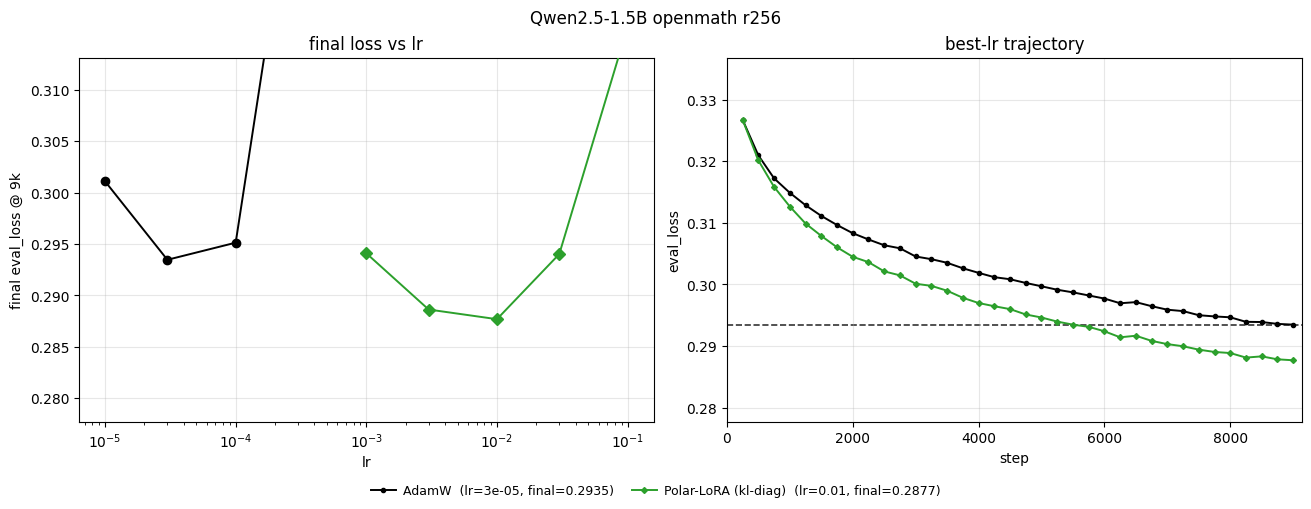

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.293472,NaN,NaN
1,Polar-LoRA (kl-diag),0.01000,0.287687,-0.005785,-3.402839


In [8]:
P.panel_n(6)   # Qwen2.5-1.5B openmath r256


### Figure 8. Llama-3-8B openmath r256  (math breadth)

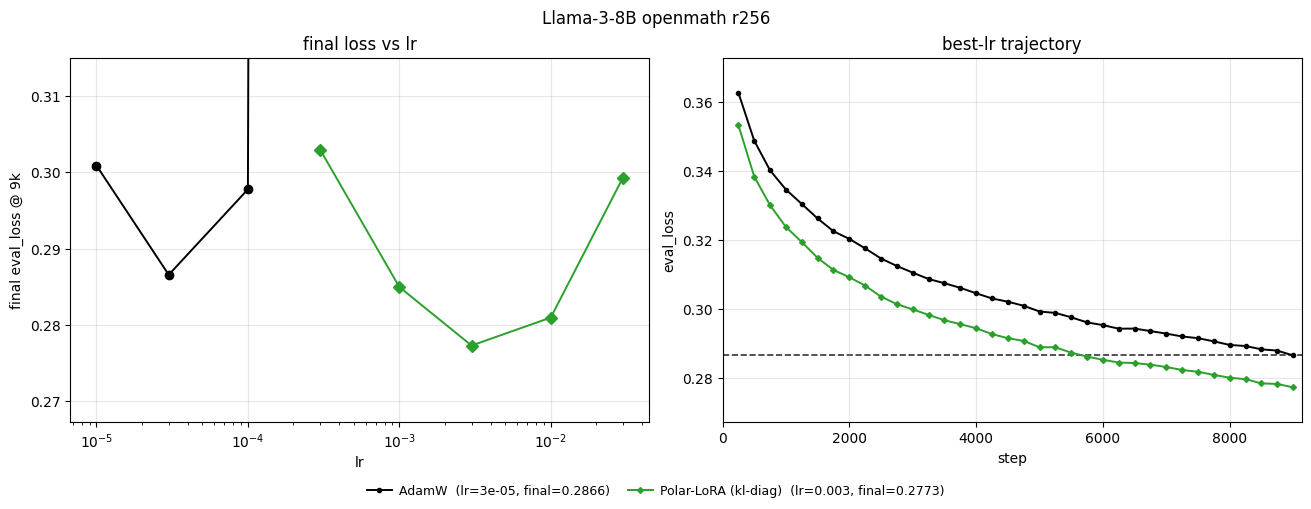

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.286564,NaN,NaN
1,Polar-LoRA (kl-diag),0.00300,0.277293,-0.00927,-5.452999


In [9]:
P.panel_n(7)   # Llama-3-8B openmath r256


### Figure 9. Llama-3.2-1B openmath r16  (rank ladder — low rank, common LoRA regime)

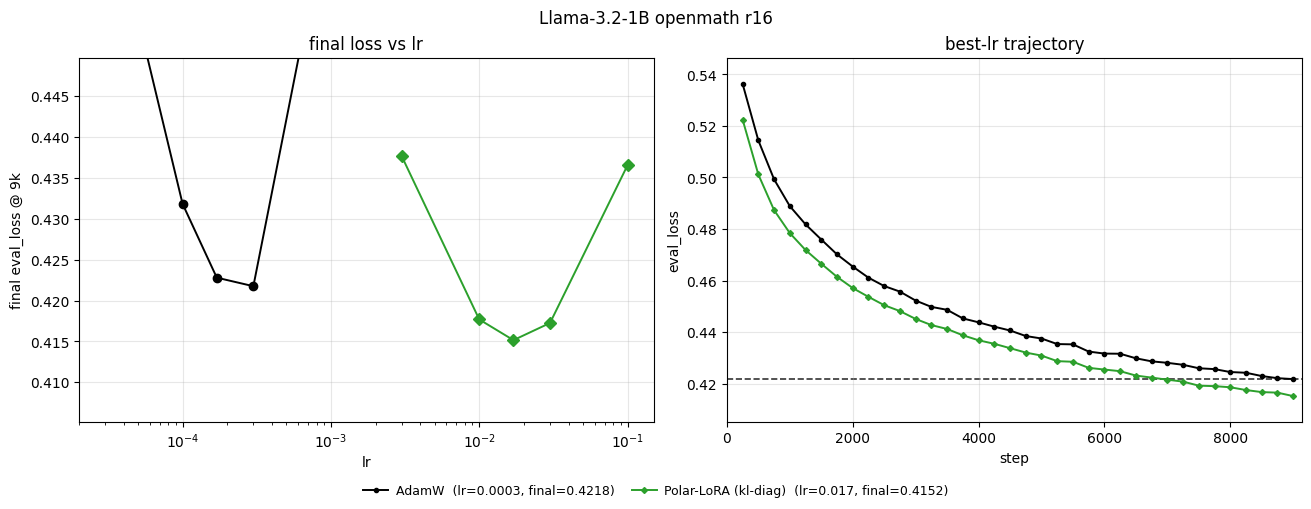

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0003,0.421763,NaN,NaN
1,Polar-LoRA (kl-diag),0.0170,0.415162,-0.006601,-3.883152


In [10]:
P.panel_n(8)   # Llama-3.2-1B openmath r16


### Figure 10. Llama-3.2-1B openmath r32  (rank ladder — low rank)

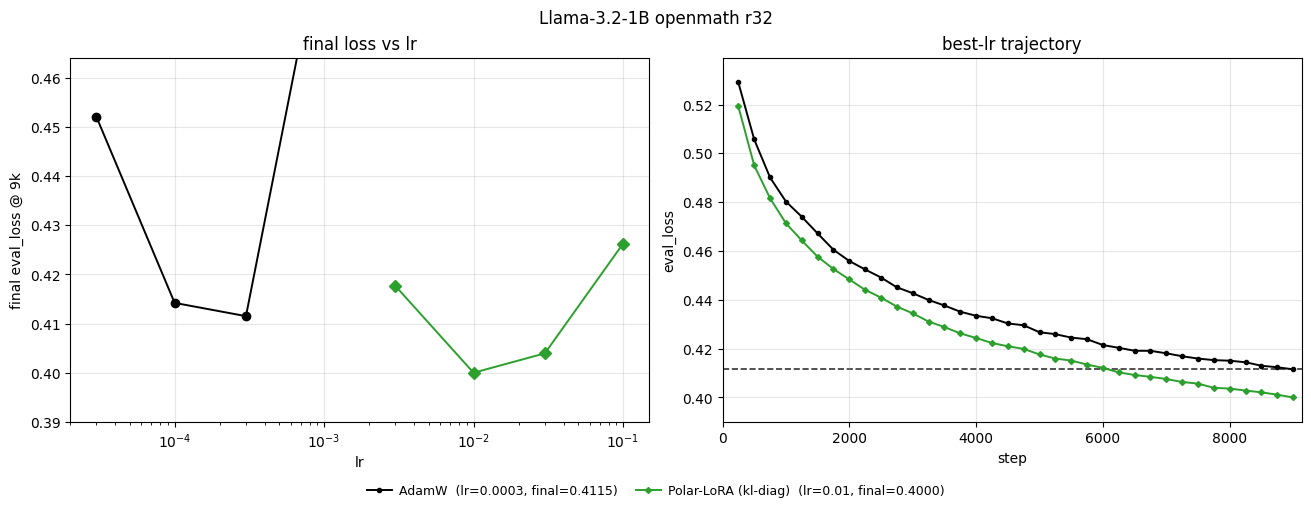

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0003,0.411517,NaN,NaN
1,Polar-LoRA (kl-diag),0.0100,0.399991,-0.011526,-6.779981


In [11]:
P.panel_n(9)   # Llama-3.2-1B openmath r32


### Figure 11. Llama-3.2-1B openmath r64  (rank ladder)

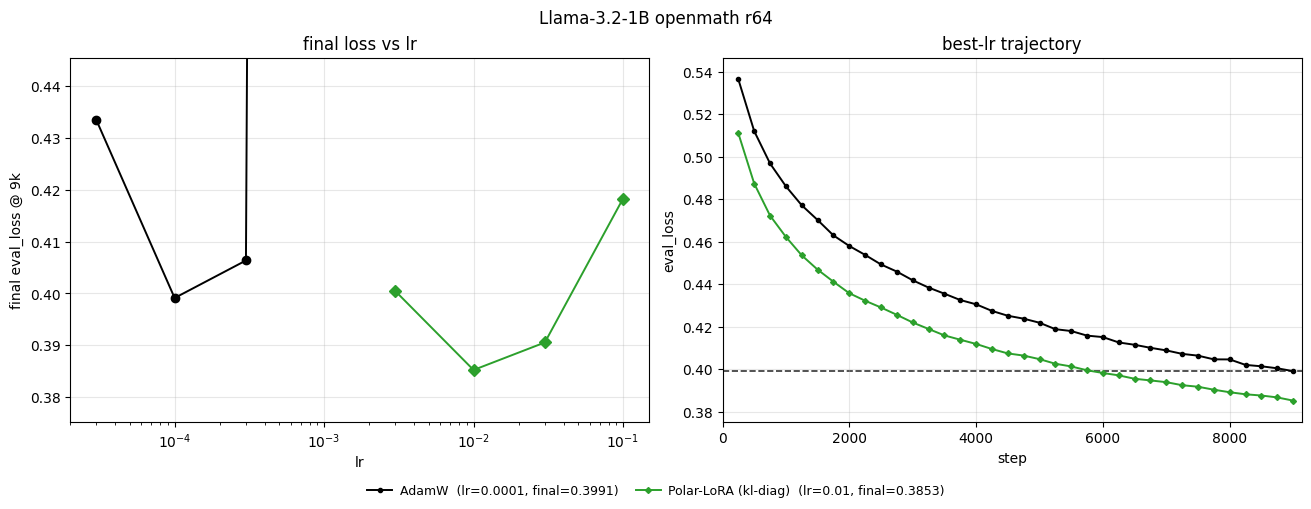

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.399128,NaN,NaN
1,Polar-LoRA (kl-diag),0.0100,0.385254,-0.013874,-8.160944


In [12]:
P.panel_n(10)   # Llama-3.2-1B openmath r64


### Figure 12. Llama-3.2-1B openmath r128  (rank ladder)

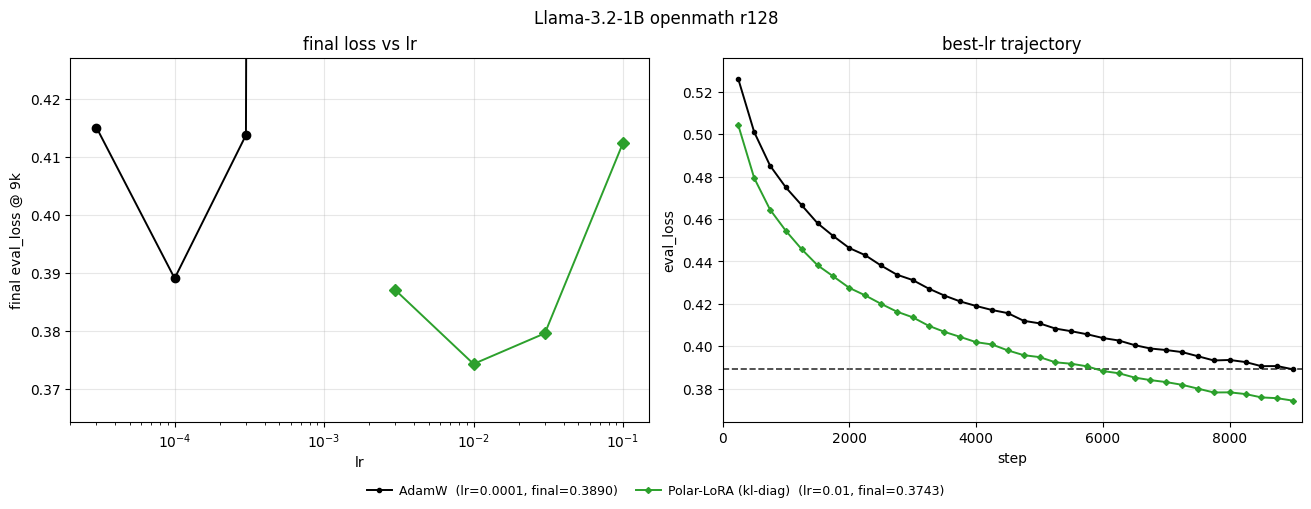

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.389044,NaN,NaN
1,Polar-LoRA (kl-diag),0.0100,0.374259,-0.014785,-8.696915


In [13]:
P.panel_n(11)   # Llama-3.2-1B openmath r128


### Figure 13. Llama-3.2-1B openmath r256  (rank ladder)

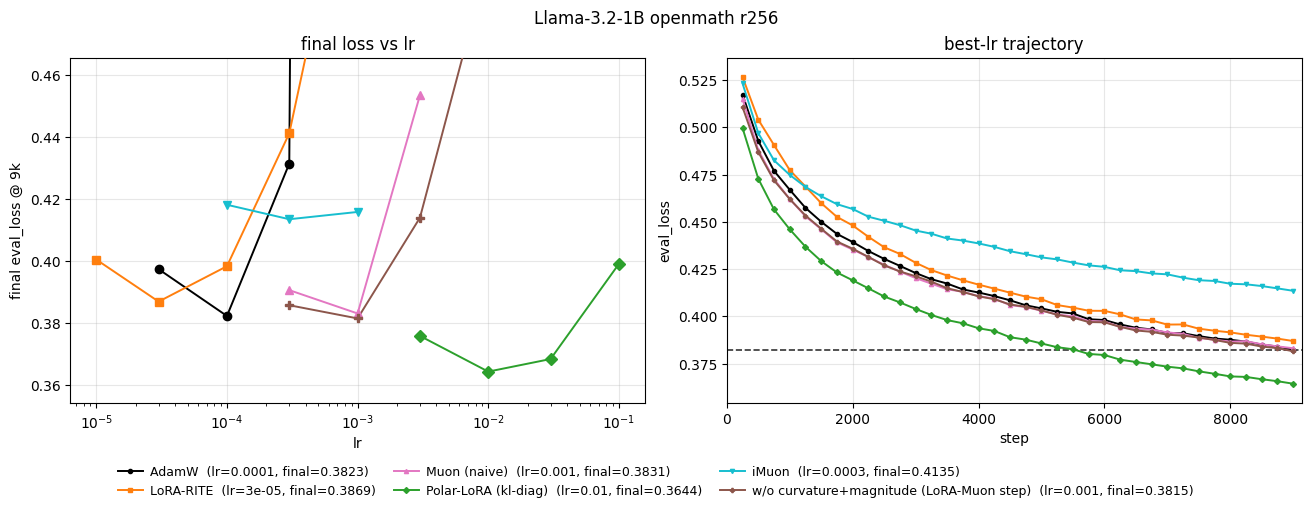

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00010,0.382301,NaN,NaN
1,LoRA-RITE,0.00003,0.386939,0.004638,2.728313
2,Muon (naive),0.00100,0.383107,0.000807,0.474588
3,Polar-LoRA (kl-diag),0.01000,0.364357,-0.017944,-10.555354
4,iMuon,0.00030,0.413505,0.031204,18.355461
5,w/o curvature+magnitude (LoRA-Muon step),0.00100,0.381511,-0.000790,-0.464564


In [14]:
P.panel_n(12)   # Llama-3.2-1B openmath r256


## Figure 14. E2 ablation — Llama-3.2-1B openmath, per rank (leave-one-out)

One panel per rank. Arms: **Polar-LoRA (kl-diag)** vs **w/o curvature control** (drop the
curvature EMAs → identity metric; the novelty over the iMuon family) vs
**w/o magnitude control** (`cw_unpinned`: remove the operator-norm magnitude rule → true-scale,
no pin) vs **w/o curvature+magnitude (LoRA-Muon step)**. Δ vs Polar-LoRA (kl-diag) in σ-units,
step-matched (`allow_partial`). The w/o-curvature arm runs at r256 only (the canonical rank).
Polar is *not* ablated (cited to the spectral-method literature).

no data yet (omitted): w/o magnitude control


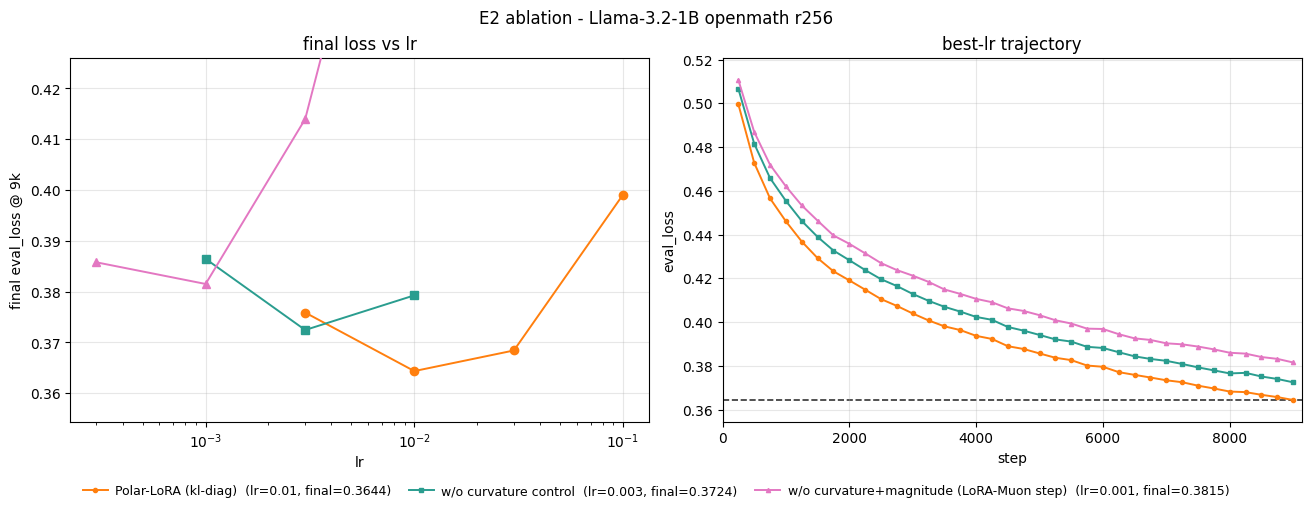

,variant,best_lr,final,delta,delta_sigma
0,Polar-LoRA (kl-diag),0.010,0.364357,NaN,NaN
1,w/o curvature control,0.003,0.372446,0.008089,4.758315
2,w/o curvature+magnitude (LoRA-Muon step),0.001,0.381511,0.017154,10.090790


In [15]:
P.ablation_panel(256)


## Figure 15. Derivation ablations — Llama-3.2-1B openmath r256

Two arms, each removing exactly one premise of the PoLoRA derivation
(main.tex §2.3 "Per-Sample Loss Control" and the "Direction" paragraph), with
every other knob held at the protagonist config (β₁=0.9, δ=1e-4, `gram_ns`
inverse-sqrt, PolarExpress-8, Nesterov, k=1, 9000 steps).

| arm | `--optimizer` | left/right metric for $\Delta A$ | direction operator |
|---|---|---|---|
| Polar-LoRA (kl-diag) | `kl-diag-polar-lora` | $C_B=B^\top P B$, $Q$ | $\mathrm{msign}$ |
| w/o per-sample loss control (averaged) | `kl-diag-lora` | $C_B=B^\top P B$, $Q$ | identity |
| w/o product structure (factorwise) | `kl-shampoo-polar-lora` | $P_A$ (own $r\times r$ EMA), $Q$ | $\mathrm{msign}$ |
| w/o outer un-whiten (bare msign) | `kl-diag-polar-flatout-lora` | $C_B=B^\top P B$, $Q$ (inner only) | $\mathrm{msign}$, not un-whitened |

**Averaged loss.** Replacing the per-sample bound $\max_i |\langle G_i,\Delta W\rangle|\le\tau$
with the batch RMS $\bigl(\tfrac1n\sum_i \langle G_i,\Delta W\rangle^2\bigr)^{1/2}\le\tau$
makes the constraint exactly $\|P^{1/2}\Delta W Q^{1/2}\|_F\le\tau$ under
$\Sigma\approx Q\otimes P$ — no outergradient set and no rank-one/leverage lemma
are needed, since those exist only to relax the max. Spectral becomes Frobenius,
so the LMO solution loses $\mathrm{msign}$:
$D_A = C_B^{-1}\widehat M_A Q^{-1}$, $D_B = P^{-1}\widehat M_B C_A^{-1}$.
The magnitude rule and the $p,q$ updates are unchanged.

**Product structure.** Applying the same per-sample LMO to each factor as its own
weight matrix replaces the partner Gram $C_B=B^\top P B$ by an $r\times r$ EMA fitted
from $A$'s own gradients, $P_A\leftarrow\beta_2P_A+\frac{1-\beta_2}{d_{\rm in}}G_AQ^{-1}G_A^\top$
(and $C_A$ by the mirror $Q_B$), giving
$D_A = P_A^{-1/2}\,\mathrm{msign}(P_A^{-1/2}\widehat M_A Q^{-1/2})\,Q^{-1/2}$.
The $d$-side metric $(P,Q)$ is still shared between the $A$- and $B$-updates — only
the two $r\times r$ slots become per-factor. The magnitude rule
$\rho=\eta/(\|A\|_2+\|B\|_2)$ is kept, so only the direction changes.

**Outer un-whitening.** Dropping the trailing $C_B^{-1/2}(\cdot)Q^{-1/2}$ leaves
$D_A=\mathrm{msign}(C_B^{-1/2}\widehat M_A Q^{-1/2})$. This is no longer the
solution of the LMO under $\|C_B^{1/2}\Delta A Q^{1/2}\|_2\le\tau$; it solves that
LMO under the *plain* $\|\Delta A\|_2\le\tau$ with a curvature-whitened gradient,
so the curvature picks the frame but the constraint leaves the curvature norm.
Because $\mathrm{msign}$ has every nonzero singular value equal to $1$,
$\|D_A\|_2=1$ by construction and the rescale $\Delta A=-\rho D_A/\|D_A\|_2$
collapses to $\Delta A=-\rho\,\mathrm{msign}(z)$: this arm needs no
$\sigma_{\max}$ estimate at all.

**Plotted:** final eval loss at 9000 steps vs learning rate (left) and the
best-lr trajectory (right), for the protagonist and the two arms, with AdamW as
the anchor; Δ vs the protagonist in σ-units.

**Why:** each arm deletes one premise of the derivation, so the position of each
curve's minimum and its best-lr trajectory separate what the per-sample
constraint contributes from what the product linearization contributes. The
discriminating feature is where each arm's best-lr final loss sits relative to
the two ends of the range — the protagonist and AdamW.

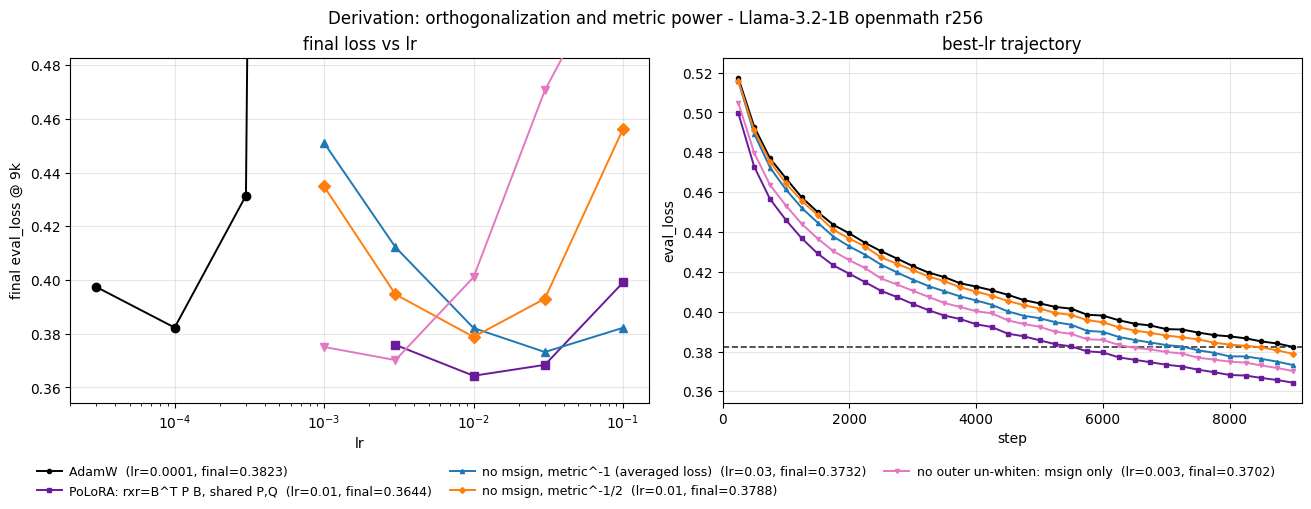

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,0.017944,10.555354
1,"PoLoRA: rxr=B^T P B, shared P,Q",0.0100,0.364357,NaN,NaN
2,"no msign, metric^-1 (averaged loss)",0.0300,0.373200,0.008843,5.201881
3,"no msign, metric^-1/2",0.0100,0.378824,0.014468,8.510331
4,no outer un-whiten: msign only,0.0030,0.370188,0.005832,3.430412


In [16]:
P.derivation_ablation_panel(256)


### Figure 16. The $r\times r$ metric slot — Llama-3.2-1B openmath r256

Figure 15 varies the orthogonalization and the metric *power*. These arms hold both
fixed and vary only what occupies the two $r\times r$ slots, $C_B$ and $C_A$. There
are three branches, selected by `--precond`:

| arm | $C_B$ | $C_A$ |
|---|---|---|
| `product` (PoLoRA) | $B^\top P B$ | $A Q A^\top$ |
| `one-sided` | $I_r$ | $I_r$ |
| `factorwise` | $P_A$ | $Q_B$ |

with the two $r\times r$ buffers of the `factorwise` branch fitted from the factor
gradients themselves,

$$P_A\leftarrow\beta_2 P_A+\frac{1-\beta_2}{d_{\rm in}}G_AQ^{-1}G_A^\top,\qquad
Q_B\leftarrow\beta_2 Q_B+\frac{1-\beta_2}{d_{\rm out}}G_B^\top P^{-1}G_B.$$

All three share **one** $(P,Q)$ and the same $p,q$ updates,

$$\hat q=\tfrac1r\mathrm{diag}(G_A^\top C_B^{-1}G_A),\qquad
\hat p=\tfrac1r\mathrm{diag}(G_B C_A^{-1}G_B^\top),$$

and the same magnitude rule $\rho=\eta/(\|A\|_2+\|B\|_2)$; the branches differ only
in which $(C_B,C_A)$ those equations are evaluated at. In `one-sided` the identity
enters the $p,q$ updates as well as the direction, so
$\hat q=\tfrac1r\mathrm{diag}(G_A^\top G_A)$ and
$D_A=\mathrm{msign}(\widehat M_AQ^{-1/2})Q^{-1/2}$.

**Plotted:** final eval loss vs learning rate, and the best-lr trajectory, with
AdamW for scale and $\Delta$ against `product` in $\sigma$-units.

This panel and Figure 17 read live, but only half of each figure does: an
in-flight arm appears in the right-hand trajectory panel with its step count in
the legend (`partial @1500`), and is ABSENT from the left-hand final-loss-vs-lr
panel and from the summary table until it reaches 9000 steps — those are built
from complete runs only. `_figure` prints which arms are in that state, so a
missing row is never silent. Nothing is read off a partial curve: an early-step
ordering is the least representative part of a run. `cell_runs` memoises per `where` for the
kernel's life — call `P.clear_runs_cache()` before re-running to pick up new evals
from a sweep that has advanced.

**Why:** the three arms differ in one thing — the contents of the two $r\times r$
slots — so the spread between them is what the slot contributes, with the $d$-side
metric and the magnitude rule held fixed across all three.


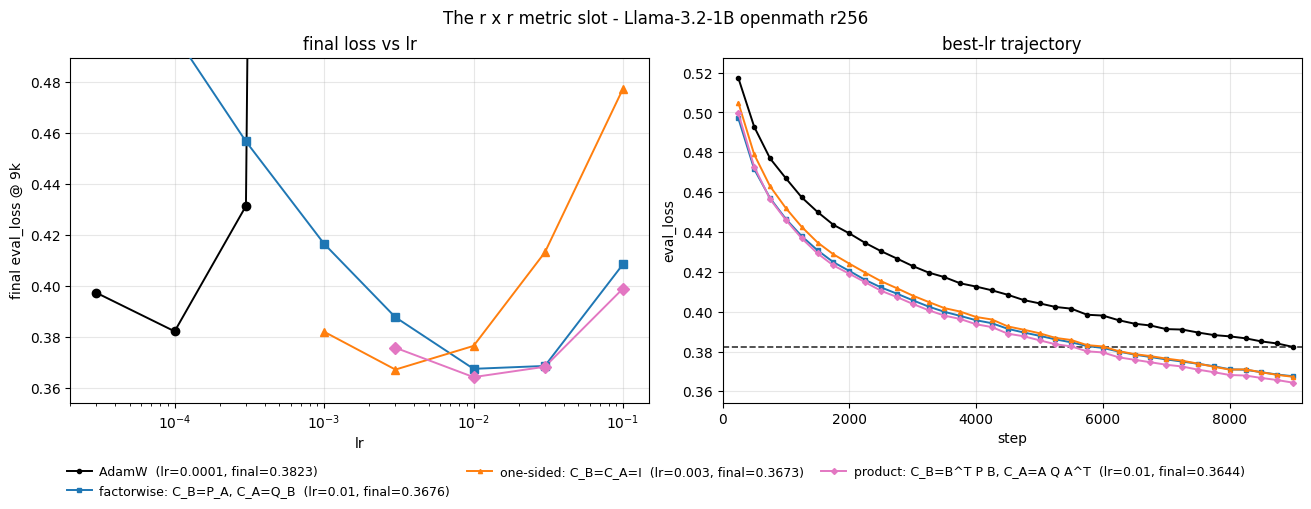

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,0.017944,10.555354
1,"factorwise: C_B=P_A, C_A=Q_B",0.0100,0.367606,0.003250,1.911507
2,one-sided: C_B=C_A=I,0.0030,0.367310,0.002954,1.737454
3,"product: C_B=B^T P B, C_A=A Q A^T",0.0100,0.364357,NaN,NaN


In [17]:
P.precond_panel(256)


### Figure 17. The $r\times r$ metric slot at $r=16$ — Llama-3.2-1B openmath

Same three `precond` branches as Figure 16, at a smaller rank. This is the axis the
derivation makes a prediction on: $C_B$ and $C_A$ are literally $r\times r$, so at
$r=16$ there is far less spectral structure in the slot than at $r=256$, and the
$O(r^2d)\to O(rd)$ saving that motivates dropping it shrinks with $r$ too.

**Plotted:** final eval loss vs learning rate and the best-lr trajectory, with AdamW
for scale and $\Delta$ against `product` in $\sigma$-units.

**Why:** the discriminating feature is the SIZE of the product-vs-one-sided gap here
against its size at $r=256$ (Figure 16). If the gap narrows as $r$ falls, the slot is
doing what §2.3 says. If one-sided is equally bad at $r=16$, it is not. Read with
Figure 16 and Figure 18 — three rank points give a direction, not a slope with a
confidence interval, which would want the $r=32$ and $r=128$ rungs as well.

`product` was already complete at this rank and was not re-run; only `factorwise` and
`one-sided` were launched.


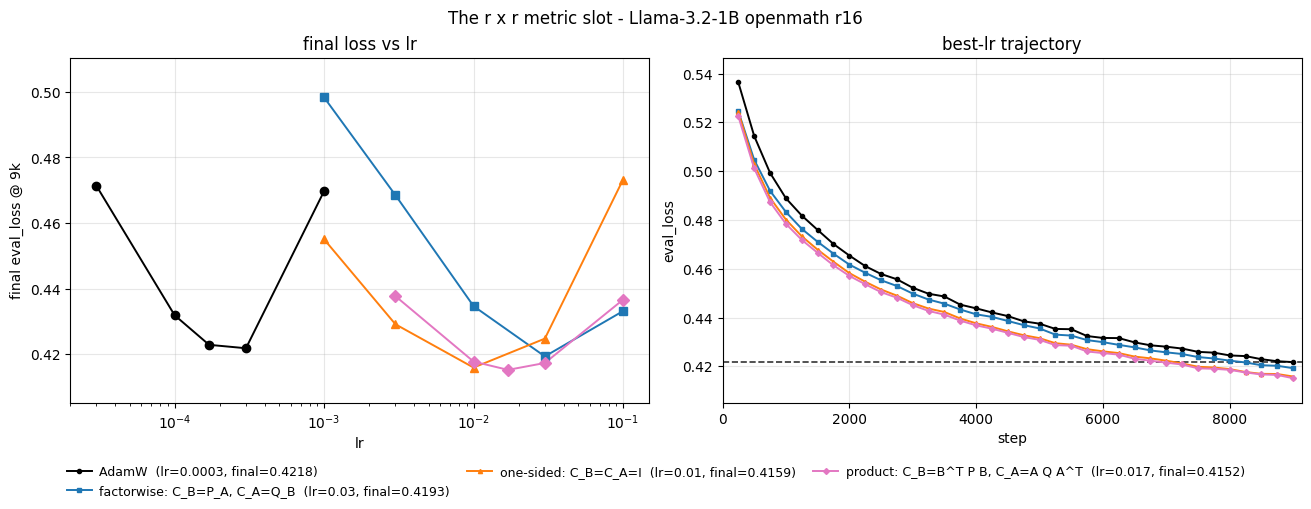

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0003,0.421763,0.006601,3.883152
1,"factorwise: C_B=P_A, C_A=Q_B",0.0300,0.419275,0.004113,2.419214
2,one-sided: C_B=C_A=I,0.0100,0.415862,0.000700,0.411740
3,"product: C_B=B^T P B, C_A=A Q A^T",0.0170,0.415162,NaN,NaN


In [18]:
P.precond_panel(16)


### Figure 18. The $r\times r$ metric slot at $r=64$ — Llama-3.2-1B openmath

Same three `precond` branches as Figure 16, at a smaller rank. This is the axis the
derivation makes a prediction on: $C_B$ and $C_A$ are literally $r\times r$, so at
$r=64$ there is far less spectral structure in the slot than at $r=256$, and the
$O(r^2d)\to O(rd)$ saving that motivates dropping it shrinks with $r$ too.

**Plotted:** final eval loss vs learning rate and the best-lr trajectory, with AdamW
for scale and $\Delta$ against `product` in $\sigma$-units.

**Why:** the discriminating feature is the SIZE of the product-vs-one-sided gap here
against its size at $r=256$ (Figure 16). If the gap narrows as $r$ falls, the slot is
doing what §2.3 says. If one-sided is equally bad at $r=64$, it is not. Read with
Figure 16 and Figure 18 — three rank points give a direction, not a slope with a
confidence interval, which would want the $r=32$ and $r=128$ rungs as well.

`product` was already complete at this rank and was not re-run; only `factorwise` and
`one-sided` were launched.


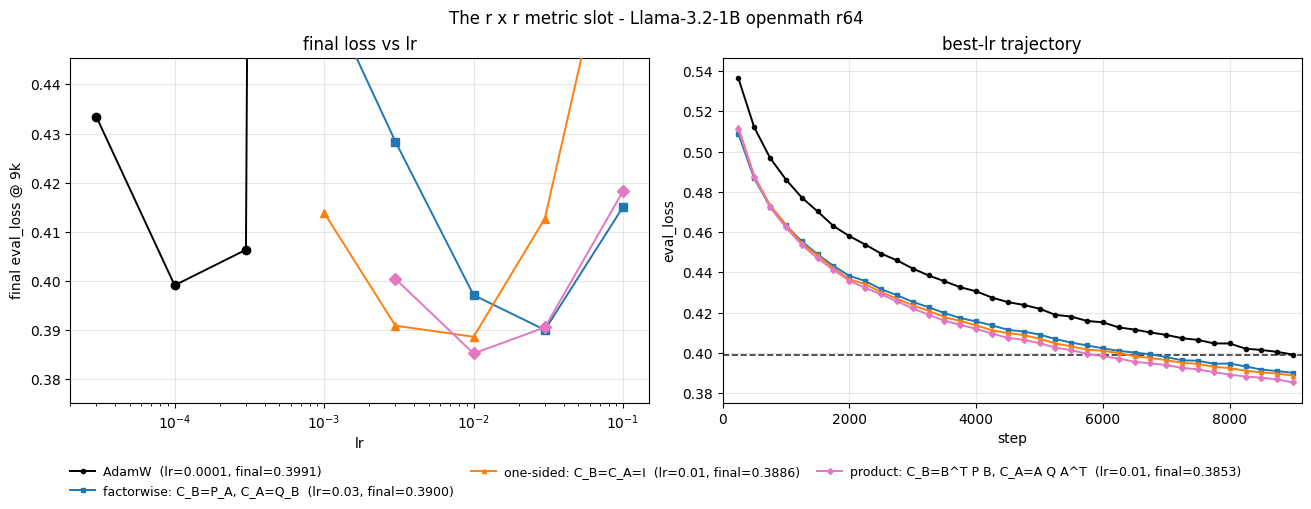

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.399128,0.013874,8.160944
1,"factorwise: C_B=P_A, C_A=Q_B",0.0300,0.390043,0.004789,2.817011
2,one-sided: C_B=C_A=I,0.0100,0.388649,0.003395,1.996805
3,"product: C_B=B^T P B, C_A=A Q A^T",0.0100,0.385254,NaN,NaN


In [19]:
P.precond_panel(64)


### Figure 19. The $r\times r$ metric slot on Qwen2.5-1.5B — openmath r256

The same three branches on a different architecture, at the rank Figure 16 uses.

**Plotted:** final eval loss vs learning rate and the best-lr trajectory, with AdamW
for scale and $\Delta$ against `product` in $\sigma$-units.

**Why:** whether the ORDERING of the three branches is a property of the method or of
Llama-3.2-1B. Unlike the rank axis this predicts nothing specific, so agreement is
weak evidence and disagreement is the informative outcome. Qwen uses its own tokenized
corpus (`..._packed_seq2048_qwen25`), so absolute losses are not comparable across
Figures 16 and 19 — only the within-figure ordering and the $\sigma$-unit gaps are.

`product` was already complete here and was not re-run.


in flight (trajectory panel only, absent from the loss-vs-lr panel and the summary table until 9000 steps): one-sided: C_B=C_A=I @8250, factorwise: C_B=P_A, C_A=Q_B @8250


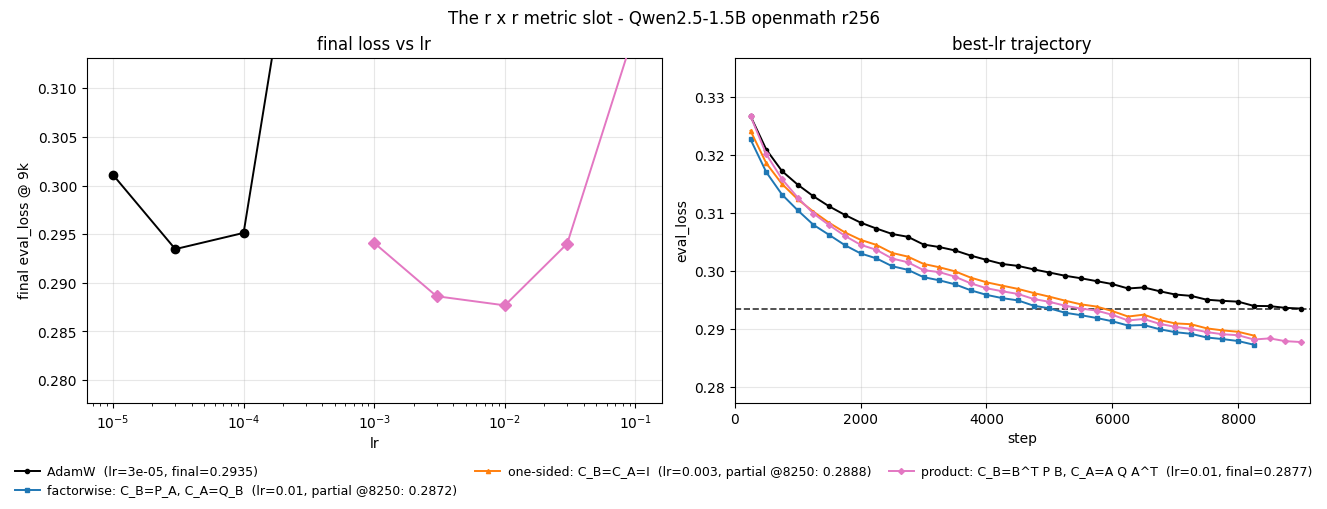

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.293472,0.005785,3.402839
1,"product: C_B=B^T P B, C_A=A Q A^T",0.01000,0.287687,NaN,NaN


In [20]:
P.precond_panel(256, model="Qwen/Qwen2.5-1.5B", model_label="Qwen2.5-1.5B")

### Figure 20. The $r\times r$ metric slot on OPC — Llama-3.2-1B r256

The `opc` half of the architecture x dataset 2x2. Figures 16 and 19 compare the same
three branches on openmath at $r=256$ for Llama-3.2-1B and Qwen2.5-1.5B, and they
disagree: `factorwise` is the worst branch on Llama and the best on Qwen. Those two
cells differ in BOTH architecture and corpus — the OpenMath set is tokenized per model
(`..._llama32` vs `..._qwen25`) — so that pair alone cannot say which causes the flip.

| | openmath | opc |
|---|---|---|
| Llama-3.2-1B | Figure 16 | Figure 20 |
| Qwen2.5-1.5B | Figure 19 | Figure 21 |

**Plotted:** final eval loss vs learning rate and the best-lr trajectory, with AdamW
for scale and $\Delta$ against `product` in $\sigma$-units.

**Why:** reading all four cells together is what discriminates. If `factorwise` wins on
both Qwen cells and loses on both Llama cells, the cause is architecture; if it tracks
openmath-against-opc, the cause is the dataset; if neither, it is an interaction and
neither single-factor story holds. `product` was already complete here (3/3) and was
not re-run. The new arms run lr $\in\{3\!\cdot\!10^{-4},10^{-3},3\!\cdot\!10^{-3},10^{-2}\}$,
which covers `product`'s recorded grid and extends one point down — the direction these
arms' optima move on openmath. `product`'s own optimum is interior at $3\!\cdot\!10^{-3}$
on both cells, so its minimum is resolved rather than sitting on an untested endpoint.


in flight (trajectory panel only, absent from the loss-vs-lr panel and the summary table until 9000 steps): one-sided: C_B=C_A=I @3000, factorwise: C_B=P_A, C_A=Q_B @3000


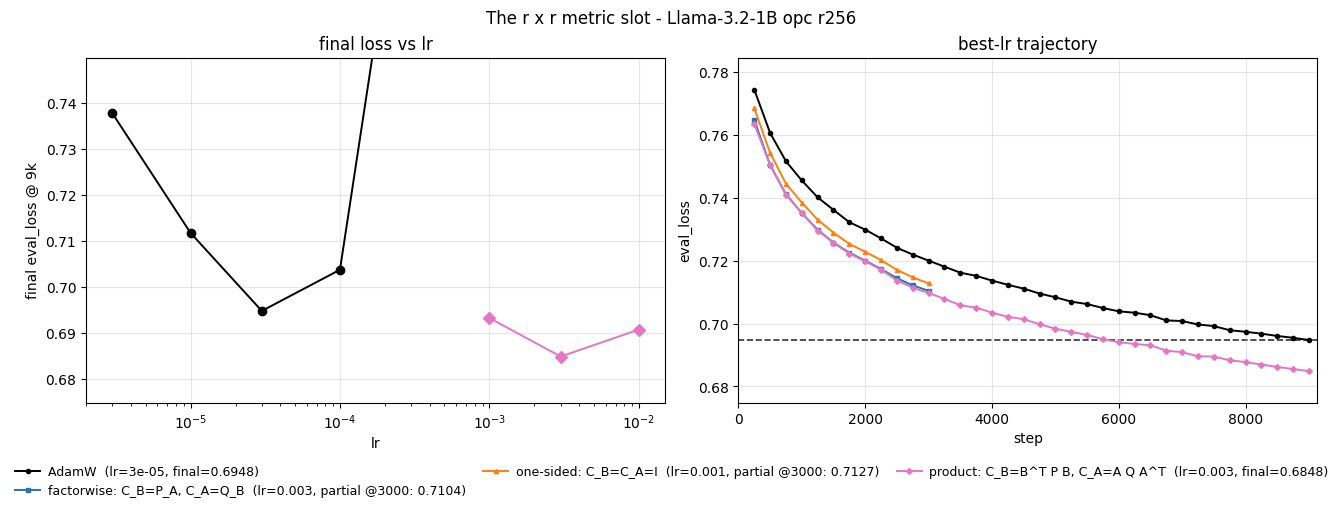

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.694754,0.009905,5.826258
1,"product: C_B=B^T P B, C_A=A Q A^T",0.00300,0.684849,NaN,NaN


In [34]:
P.precond_panel(256, data_key="opc")


### Figure 21. The $r\times r$ metric slot on OPC — Qwen2.5-1.5B r256

The `opc` half of the architecture x dataset 2x2. Figures 16 and 19 compare the same
three branches on openmath at $r=256$ for Llama-3.2-1B and Qwen2.5-1.5B, and they
disagree: `factorwise` is the worst branch on Llama and the best on Qwen. Those two
cells differ in BOTH architecture and corpus — the OpenMath set is tokenized per model
(`..._llama32` vs `..._qwen25`) — so that pair alone cannot say which causes the flip.

| | openmath | opc |
|---|---|---|
| Llama-3.2-1B | Figure 16 | Figure 20 |
| Qwen2.5-1.5B | Figure 19 | Figure 21 |

**Plotted:** final eval loss vs learning rate and the best-lr trajectory, with AdamW
for scale and $\Delta$ against `product` in $\sigma$-units.

**Why:** reading all four cells together is what discriminates. If `factorwise` wins on
both Qwen cells and loses on both Llama cells, the cause is architecture; if it tracks
openmath-against-opc, the cause is the dataset; if neither, it is an interaction and
neither single-factor story holds. `product` was already complete here (3/3) and was
not re-run. The new arms run lr $\in\{3\!\cdot\!10^{-4},10^{-3},3\!\cdot\!10^{-3},10^{-2}\}$,
which covers `product`'s recorded grid and extends one point down — the direction these
arms' optima move on openmath. `product`'s own optimum is interior at $3\!\cdot\!10^{-3}$
on both cells, so its minimum is resolved rather than sitting on an untested endpoint.


in flight (trajectory panel only, absent from the loss-vs-lr panel and the summary table until 9000 steps): one-sided: C_B=C_A=I @1500, factorwise: C_B=P_A, C_A=Q_B @1500


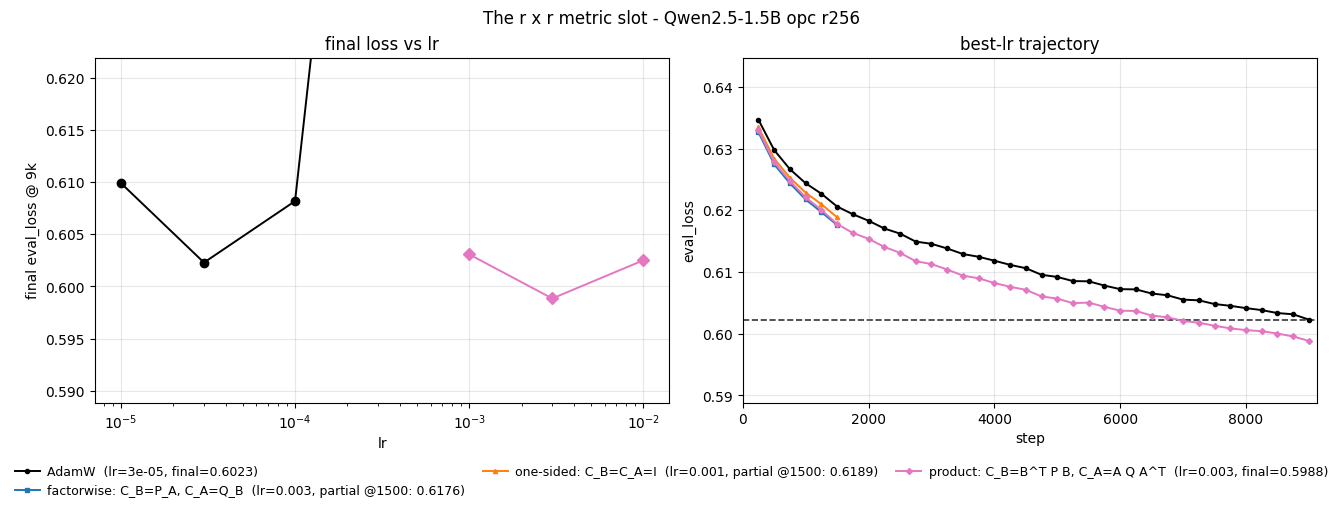

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.602292,0.003447,2.027497
1,"product: C_B=B^T P B, C_A=A Q A^T",0.00300,0.598845,NaN,NaN


In [33]:
P.precond_panel(256, model="Qwen/Qwen2.5-1.5B", data_key="opc", model_label="Qwen2.5-1.5B")


### Figure 22. Diagonal $\mathrm{msign}$ — Llama-3.2-1B openmath r256

`--msign` is orthogonal to `--precond`: that one picks the curvature structure, this
one picks how accurately the matrix sign is applied. Both branches first form the same
two whitened momenta

$$Z_A=C_B^{-1/2}\widehat M_AQ^{-1/2},\qquad Z_B=P^{-1/2}\widehat M_BC_A^{-1/2},$$

and both finish with the same $D_A=C_B^{-1/2}U_AQ^{-1/2}$, $D_B=P^{-1/2}U_BC_A^{-1/2}$,
the same spectral normalization and the same $\rho$ rule. Only $U$ differs:

| `--msign` | $U_A$ | $U_B$ |
|---|---|---|
| `full` | $\mathrm{msign}(Z_A)$ | $\mathrm{msign}(Z_B)$ |
| `diag` | $\mathrm{Diag}(\mathrm{diag}(Z_AZ_A^\top))^{-1/2}Z_A$ | $Z_B\,\mathrm{Diag}(\mathrm{diag}(Z_B^\top Z_B))^{-1/2}$ |

Since $Z_A$ is wide, $\mathrm{msign}(Z_A)=(Z_AZ_A^\top)^{-1/2}Z_A$; `diag` approximates
that $r\times r$ Gram by its diagonal, which is just **row normalization** of $Z_A$.
$Z_B$ is tall, so the mirror is **column normalization**. Neither involves an
$r\times r$ matmul or an inverse square root.

**Plotted:** final eval loss vs learning rate, and the best-lr trajectory, for
`full`/`diag` at both `precond=product` and `precond=one-sided`, with AdamW for
scale and $\Delta$ against `product, msign` in $\sigma$-units.

**Why:** running the approximation at both ends of the `precond` axis separates
"the matrix sign can be cheapened" from "the matrix sign can be cheapened once the
$r\times r$ slot is already gone". `one-sided, diagonal msign` is the branch with no
$r\times r$ matmul or inverse square root anywhere in the direction, i.e. $O(rd)$
rather than $O(r^2d)$ preconditioning.


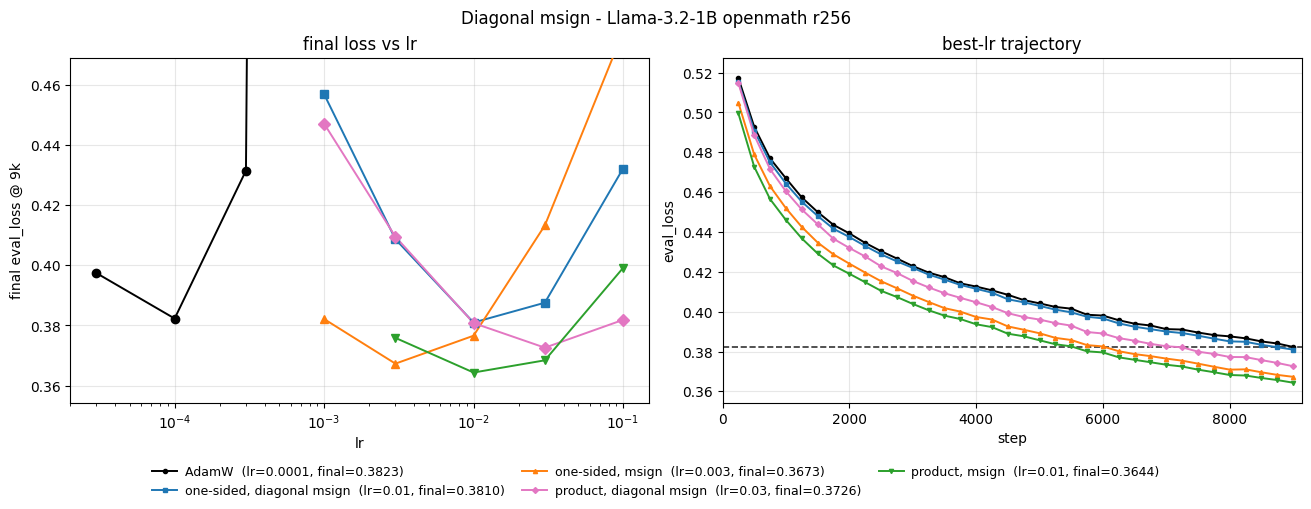

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,0.017944,10.555354
1,"one-sided, diagonal msign",0.0100,0.380976,0.016620,9.776300
2,"one-sided, msign",0.0030,0.367310,0.002954,1.737454
3,"product, diagonal msign",0.0300,0.372614,0.008257,4.857073
4,"product, msign",0.0100,0.364357,NaN,NaN


In [23]:
P.msign_panel(256)


## Figure 23. Per-rank final loss vs lr — Llama-3.2-1B openmath, all ranks (r16/r32/r64/r128/r256)

Two side-by-side panels, **Polar-LoRA (kl-diag)** and **AdamW**. For each, final eval loss
(9000 steps) vs lr, one curve per rank (color = rank, reversed viridis). Shared y-axis; x is
each optimizer's own lr grid. Final-step runs only (partial runs skipped). Exploratory all-ranks
view; the clean $r\ge32$ transfer figure (r16 excluded) lives in `paper_figs.ipynb`.

3 high-lr point(s) above y-window (divergence), clipped at 0.500


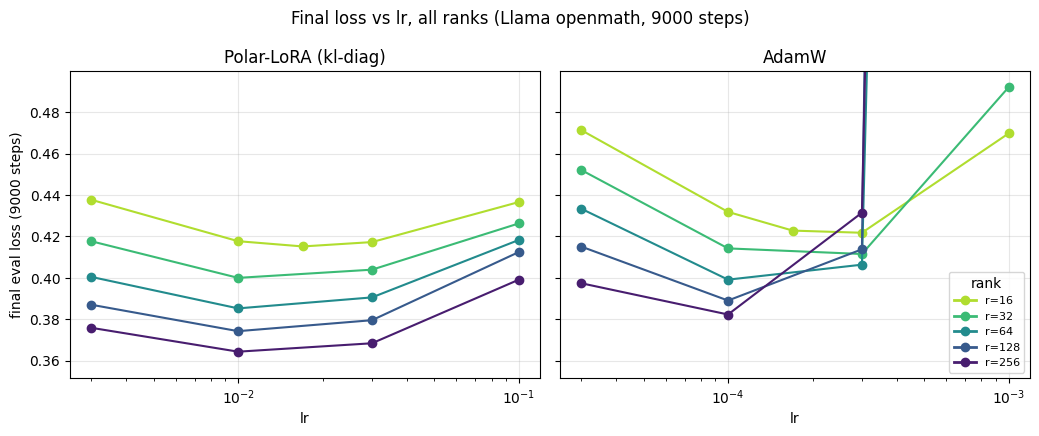

In [24]:
# Final eval loss (9000 steps) vs lr, ALL ranks (Llama openmath). Two side-by-side panels:
# Polar-LoRA (kl-diag) | AdamW. Color = rank (reversed viridis: light = low rank, dark = high).
# Only runs that reached 9000 steps count (a partial run would plot an early-step loss against
# final losses). Exploratory all-ranks view; the clean r>=32 transfer figure lives in paper_figs.ipynb
# (r16's flat basin top is under-resolved). Shared y, windowed to the converged band (high-lr
# divergence runs off the top of the panel; clipped count printed).
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
RANKS=[16,32,64,128,256]; HORIZON=9000
RANK_COLOR={r:c for r,c in zip(RANKS, cm.viridis_r(np.linspace(0.12,0.92,len(RANKS))))}
def _final_by_lr(where, rank):
    # Filters the cell_runs(_om(rank)) prefetch (cell 1) in memory instead of an own
    # load_runs(where=...) call -- same predicate, applied post-hoc; see the
    # cell_runs(_om(rank)) comment in cell 1 for why this is behavior-identical.
    pred = {**where, 'lora_r': rank, 'model_name': 'meta-llama/Llama-3.2-1B',
            'data_dir': (lambda d: 'openmath' in str(d))}
    out={}
    for cfg,evs in cell_runs(_om(rank)):
        if not _pred_matches(cfg, pred): continue
        ev=[(e['step'],e['eval_loss']) for e in (evs or []) if e.get('eval_loss') is not None]
        if not ev or ev[-1][0] < HORIZON: continue   # final losses only (skip partial runs)
        lr=float(cfg.get('lr')); out[lr]=min(out.get(lr,9e9), ev[-1][1])
    return dict(sorted(out.items()))
_PANELS=[('Polar-LoRA (kl-diag)',PROTO),('AdamW',ADAMW)]
panel_data=[]; allv=[]; empty=[]
for label,where in _PANELS:
    dd={rank:_final_by_lr(where,rank) for rank in RANKS}
    panel_data.append((label,dd))
    for rank,d in dd.items():
        if d: allv+=list(d.values())
        else: empty.append(f'{label} r{rank}')
# robust y-window: keep the converged band readable, let high-lr divergence run off-panel
med=float(np.median(allv)); conv=[v for v in allv if v < 3*med]
lo,hi=min(allv),max(conv); rng=hi-lo
ylo,yhi=lo-0.10*rng, hi+0.06*rng   # extra bottom pad so the lowest (r256) markers clear the axis
fig,axes=plt.subplots(1,len(_PANELS),figsize=(10.5,4.4),sharey=True)
for ax,(label,dd) in zip(axes,panel_data):
    for rank in RANKS:
        d=dd[rank]
        if d: ax.plot(list(d),list(d.values()),'o-',color=RANK_COLOR[rank],label=f'r={rank}')
    ax.set_xscale('log'); ax.set_xlabel('lr'); ax.set_title(label); ax.grid(alpha=.3)
    ax.set_ylim(ylo,yhi)
axes[0].set_ylabel('final eval loss (9000 steps)')
h_rank=[Line2D([],[],color=RANK_COLOR[r],marker='o',lw=2,label=f'r={r}') for r in RANKS]
axes[-1].legend(handles=h_rank,title='rank',loc='best',fontsize=8)
fig.suptitle('Final loss vs lr, all ranks (Llama openmath, 9000 steps)')
nclip=sum(v>yhi for v in allv)
if nclip: print(f'{nclip} high-lr point(s) above y-window (divergence), clipped at {yhi:.3f}')
if empty: print('NO 9000-step data (arm not run yet):', ', '.join(empty))
plt.tight_layout(); plt.show()

## Figure 24. Gauge diagnostics (exploratory) — openmath r256, per-pair over 112 LoRA pairs

Rougher/denser than `paper_figs.fig_gauge`: raw $\sigma_{max}(A)$, $\sigma_{max}(B)$, the per-pair ratio, BaLoRA residual, and factor norms, both arms. Reads the gauge diagnostic runs' logs directly; default palette. Populates as `gauge_kldiag_r256_bw` / `gauge_loramuon_r256_bw` run.

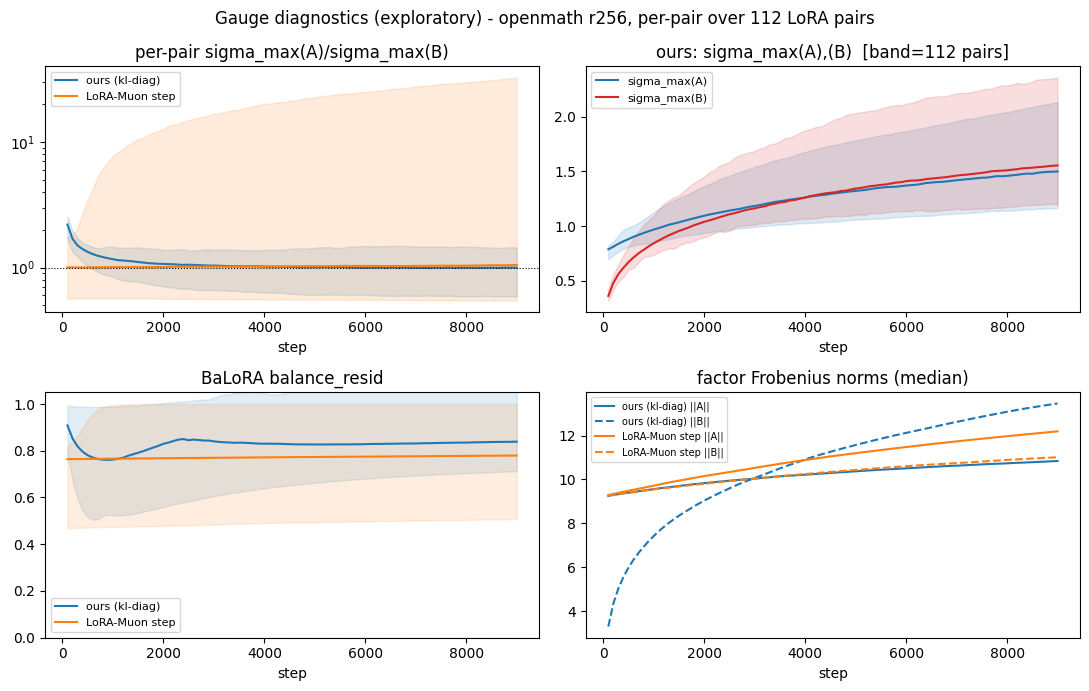

In [25]:
# Exploratory gauge diagnostics: read the gauge runs' per-step optim_step events directly
# (per-pair min/median/max over the 112 LoRA pairs). Rougher than the polished paper_figs version.
import json, glob
import numpy as np
import matplotlib.pyplot as plt
def gtraj(group):
    for f in sorted(glob.glob(str(ROOT/'logs'/group/'run_info'/'logs'/'log_*.out'))):
        rows=[json.loads(l) for l in open(f) if '"balance_resid_median"' in l]
        rows=[r for r in rows if r.get('event')=='optim_step']
        if rows:
            g=lambda k: np.array([r.get(k,np.nan) for r in rows], float)
            return {k:g(k) for k in ('step','sigma_max_A_median','sigma_max_A_min','sigma_max_A_max',
                'sigma_max_B_median','sigma_max_B_min','sigma_max_B_max','sigma_ratio_median',
                'sigma_ratio_min','sigma_ratio_max','balance_resid_median','balance_resid_min',
                'balance_resid_max','norm_A_median','norm_B_median')}
    return None
ARMS={'ours (kl-diag)':'gauge_kldiag_r256_bw','LoRA-Muon step':'gauge_loramuon_r256_bw'}
D={k:gtraj(v) for k,v in ARMS.items()}
fig,ax=plt.subplots(2,2,figsize=(11,7))
for i,(lab,d) in enumerate(D.items()):       # per-pair sigma ratio
    if d is None: continue
    ax[0,0].fill_between(d['step'],d['sigma_ratio_min'],d['sigma_ratio_max'],color=f'C{i}',alpha=.15)
    ax[0,0].plot(d['step'],d['sigma_ratio_median'],f'C{i}',label=lab)
ax[0,0].axhline(1,color='k',ls=':',lw=.8); ax[0,0].set_yscale('log')
ax[0,0].set_title('per-pair sigma_max(A)/sigma_max(B)'); ax[0,0].set_xlabel('step'); ax[0,0].legend(fontsize=8)
d=D['ours (kl-diag)']                          # sigma_max A,B for ours (convergence)
if d is not None:
    ax[0,1].fill_between(d['step'],d['sigma_max_A_min'],d['sigma_max_A_max'],color='C0',alpha=.15)
    ax[0,1].plot(d['step'],d['sigma_max_A_median'],'C0',label='sigma_max(A)')
    ax[0,1].fill_between(d['step'],d['sigma_max_B_min'],d['sigma_max_B_max'],color='C3',alpha=.15)
    ax[0,1].plot(d['step'],d['sigma_max_B_median'],'C3',label='sigma_max(B)')
ax[0,1].set_title('ours: sigma_max(A),(B)  [band=112 pairs]'); ax[0,1].set_xlabel('step'); ax[0,1].legend(fontsize=8)
for i,(lab,d) in enumerate(D.items()):       # balance_resid
    if d is None: continue
    ax[1,0].fill_between(d['step'],d['balance_resid_min'],d['balance_resid_max'],color=f'C{i}',alpha=.13)
    ax[1,0].plot(d['step'],d['balance_resid_median'],f'C{i}',label=lab)
ax[1,0].axhline(0,color='k',ls=':',lw=.8); ax[1,0].set_ylim(0,1.05)
ax[1,0].set_title('BaLoRA balance_resid'); ax[1,0].set_xlabel('step'); ax[1,0].legend(fontsize=8)
for i,(lab,d) in enumerate(D.items()):       # factor norms
    if d is None: continue
    ax[1,1].plot(d['step'],d['norm_A_median'],f'C{i}',label=f'{lab} ||A||')
    ax[1,1].plot(d['step'],d['norm_B_median'],f'C{i}',ls='--',label=f'{lab} ||B||')
ax[1,1].set_title('factor Frobenius norms (median)'); ax[1,1].set_xlabel('step'); ax[1,1].legend(fontsize=7)
fig.suptitle('Gauge diagnostics (exploratory) - openmath r256, per-pair over 112 LoRA pairs')
plt.tight_layout(); plt.show()

## Figure 25. Does the op-norm self-balancing weaken at small rank? (r16 vs r256)

Protagonist (kl-diag) at matched lr=0.01, openmath. Op-norm ratio $\sigma_{max}(B)/\sigma_{max}(A)$ (ratio-of-medians; r16 predates the per-pair field) over training. r256 self-balances to ~1; r16 plateaus at ~0.88 (residual imbalance) — consistent with the mild r16 lr-shift (gauge self-corrects less at low rank).

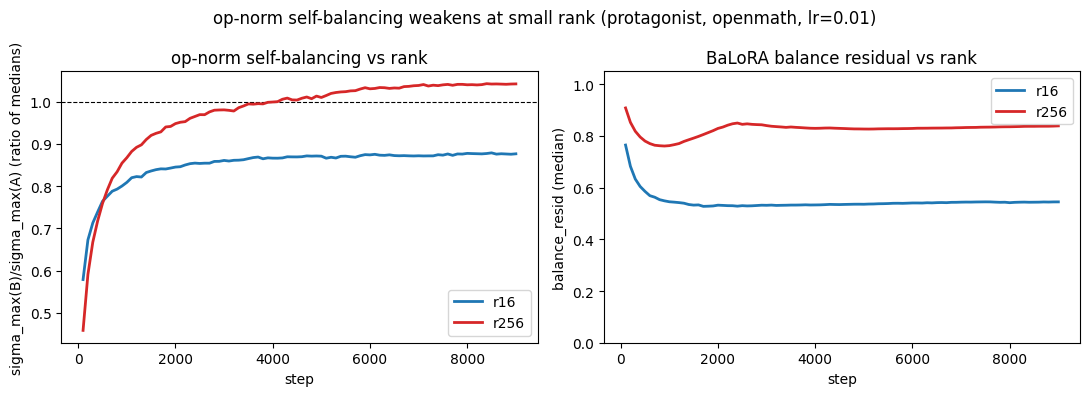

In [26]:
# r16 vs r256 op-norm self-balancing (protagonist, matched lr=0.01). ratio-of-medians
# sigma_max(B)/sigma_max(A) -> 1 = balanced. r16 uses the old-commit run (no per-pair field).
import json, glob
import numpy as np
import matplotlib.pyplot as plt
def otraj(group, lr_want=0.01):
    for f in sorted(glob.glob(str(ROOT/'logs'/group/'run_info'/'logs'/'log_*.out'))):
        lr=None; S=[]; rat=[]; br=[]
        for l in open(f):
            if '"event": "config"' in l:
                try: lr=float(json.loads(l).get('lr'))
                except: pass
            elif 'sigma_max_A_median' in l and '"event": "optim_step"' in l:
                e=json.loads(l); S.append(e['step'])
                rat.append(e['sigma_max_B_median']/e['sigma_max_A_median']); br.append(e['balance_resid_median'])
        if lr is not None and abs(lr-lr_want)<1e-9 and S:
            return np.array(S), np.array(rat), np.array(br)
    return None
ARMS=[('r16','e1_kldiag_llama32_openmath_r16r32_bw','C0'),
      ('r256','e1_kldiag_llama32_openmath_r256_bw','C3')]
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].axhline(1,color='k',ls='--',lw=.8)
for lab,grp,c in ARMS:
    d=otraj(grp)
    if d is None: continue
    ax[0].plot(d[0],d[1],c,lw=2,label=lab); ax[1].plot(d[0],d[2],c,lw=2,label=lab)
ax[0].set_xlabel('step'); ax[0].set_ylabel('sigma_max(B)/sigma_max(A) (ratio of medians)')
ax[0].set_title('op-norm self-balancing vs rank'); ax[0].legend()
ax[1].set_ylim(0,1.05); ax[1].set_xlabel('step'); ax[1].set_ylabel('balance_resid (median)')
ax[1].set_title('BaLoRA balance residual vs rank'); ax[1].legend()
fig.suptitle('op-norm self-balancing weakens at small rank (protagonist, openmath, lr=0.01)')
plt.tight_layout(); plt.show()

## Figure 26. Solved magnitude rule (cw_solved_rho) — live sweep tracking, Llama-3.2-1B openmath r256

| | |
|---|---|
| solved arm | `logs/solvedrho_kldiag_llama32_openmath_r256_bw` + `..._lrext_bw` — `kl-diag-polar-lora` + `--cw_solved_rho`, lr ∈ {3e-4, 1e-3, 3e-3, 1e-2, 3e-2}, seed 0 |
| baseline arm | `logs/e1_kldiag_llama32_openmath_r256_bw` — same optimizer, bound $\rho=\eta/(\sigma_{max}(A)+\sigma_{max}(B))$, same lr grid |
| setting | Llama-3.2-1B, OpenMathInstruct-2 `packed_v1.1`, $r=256$, 9000 steps, eval every 250 |

Reads the two groups' `log_*.out` files directly (live-safe, tolerant of mid-write lines; re-run both cells to refresh — the loader/cache is not involved).

**Plotted:** held-out `eval_loss` vs step. Colour is the learning rate, so a matched
pair shares a colour; linestyle is the arm (solved solid, bound dashed). Every lr each
arm has is drawn — nothing is filtered out of the panel.

**Why:** the solved rule sizes the factor step by the root of $\rho t + \rho^2 = \eta$ with $t = \|B U_A + U_B A\|_2$ measured, keeping $\|\Delta(BA)\|_2 \le \eta$ while spending budget the bound rule leaves as triangle-inequality slack. Matched-lr solved curves at or below the dashed baseline would support the resize;
divergence/NaN (most likely at lr 3e-2, where the realized product step grows most)
would falsify the sizing being safe at this scale.

The panel used to exclude the solved arm's lr 1e-2 and 3e-2 as "off-target high-lr
arms". That is not what the logs show: all five solved runs reached 9000 steps without
diverging, so the stated falsification test came back negative rather than
inapplicable. The exclusion also removed both matched learning rates where the bound
baseline wins (by 0.030 at 1e-2 and 0.084 at 3e-2), leaving one matched lr — 3e-3, the
one where solved wins, by 0.007. Read at each arm's own best lr, bound 1e-2 (0.3643)
beats solved 3e-3 (0.3692).

In [27]:
# Live tracking (compute): eval trajectories straight from the groups' logs.
# Direct log read (same pattern as the gauge cells) — live-safe mid-run; the
# loader/logs-cache is bypassed on purpose so re-running refreshes.
import json, glob

SOLVED_GROUPS = ['solvedrho_kldiag_llama32_openmath_r256_bw',
                 'solvedrho_kldiag_llama32_openmath_r256_lrext_bw']  # lr ext {3e-4, 1e-3}
BOUND_GROUP = 'e1_kldiag_llama32_openmath_r256_bw'

def _eval_trajs(group):
    """{lr: (steps, losses)} from each log_*.out's config + eval events."""
    out = {}
    for f in sorted(glob.glob(str(ROOT/'logs'/group/'run_info'/'logs'/'log_*.out'))):
        lr = None; S = []; L = []
        for line in open(f):
            if '"event": "config"' in line:
                try: lr = float(json.loads(line).get('lr'))
                except Exception: pass
            elif '"event": "eval"' in line:
                try:
                    e = json.loads(line)
                    if e.get('eval_loss') is not None:
                        S.append(e['step']); L.append(e['eval_loss'])
                except Exception: pass  # mid-write partial line
        if lr is not None and S:
            out[lr] = (S, L)
    return dict(sorted(out.items()))

solved_trajs = {}
for g in SOLVED_GROUPS:
    solved_trajs.update(_eval_trajs(g))
solved_trajs = dict(sorted(solved_trajs.items()))
bound_trajs = _eval_trajs(BOUND_GROUP)
for lab, d in (('solved', solved_trajs), ('bound', bound_trajs)):
    print(lab, {lr: (S[-1], round(L[-1], 4)) for lr, (S, L) in d.items()})


solved {0.0003: (9000, 0.4128), 0.001: (9000, 0.3783), 0.003: (9000, 0.3692), 0.01: (9000, 0.3941), 0.03: (9000, 0.4523)}
bound {0.003: (9000, 0.3759), 0.01: (9000, 0.3643), 0.03: (9000, 0.3684)}


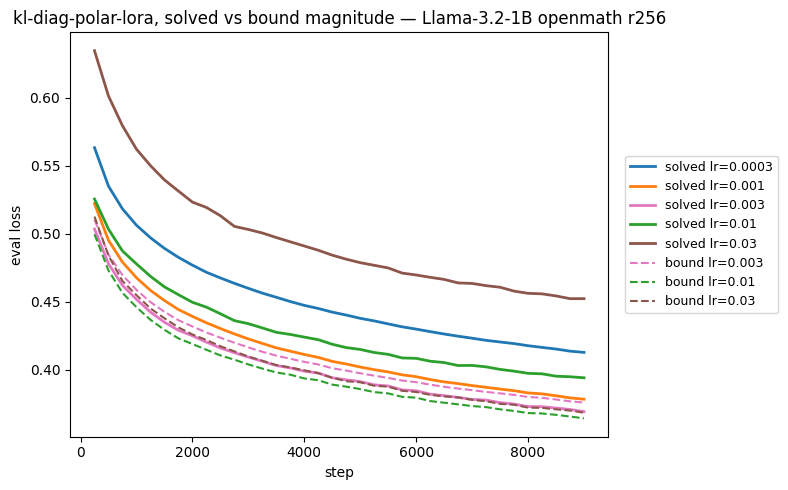

solved: best lr=0.003 final=0.3692
bound: best lr=0.01 final=0.3643


In [28]:
# Live tracking (plot): solved vs bound-rho baseline.
# Colour is the LEARNING RATE, so a matched pair shares a colour and can be read
# against each other directly; linestyle is the ARM. Every lr each arm has is
# plotted. There is no exclusion list: filtering the solved arm's 1e-2 and 3e-2
# removed both matched lrs where the baseline wins and left the single one where
# solved wins, which answers the opposite of the question in the caption above.
import matplotlib.pyplot as plt
from lora_playground.plotting import distinct_palette

lrs = sorted(set(solved_trajs) | set(bound_trajs))
COLOR = dict(zip(lrs, distinct_palette(len(lrs), reserved=[], source='tab10')))

fig, ax = plt.subplots(figsize=(8, 5))
for arm, trajs, ls, lw in (('solved', solved_trajs, '-', 2.0),
                           ('bound', bound_trajs, '--', 1.5)):
    for lr, (S, L) in sorted(trajs.items()):
        ax.plot(S, L, ls=ls, lw=lw, color=COLOR[lr], label=f'{arm} lr={lr:g}')
ax.set_xlabel('step'); ax.set_ylabel('eval loss')
ax.set_title('kl-diag-polar-lora, solved vs bound magnitude — Llama-3.2-1B openmath r256')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout(); plt.show()

# Best-lr read, which is how the two rules are actually compared.
for arm, trajs in (('solved', solved_trajs), ('bound', bound_trajs)):
    best = min(trajs.items(), key=lambda kv: kv[1][1][-1])
    print(f'{arm}: best lr={best[0]:g} final={best[1][1][-1]:.4f}')


## Live sweep tracking — in-flight E2 arms, Llama-3.2-1B openmath r256

Figures 20–22 share one helper, defined next.

In [29]:
# Figures 21-23 below track in-flight sweeps. cell_runs() memoises per cell;
# call P.clear_runs_cache() once when a sweep has advanced and you want fresh
# numbers. (It used to force a re-read on EVERY call, which made these the
# slowest cells in the notebook.)


### Figure 27. Live tracking — protagonist $\beta_2$ sweep

Protagonist with $\beta_2\in\{0.81,0.909,0.956,0.979\}$ against the shipped $0.99$.
The $P,Q$ metric is accumulated *after* the step that consumes it
(`optim.py:2020-2024` applies, `:2068-2069` then folds in $g_t$), so it is stale by
one step — 1% of the $\approx100$-step EMA window at $\beta_2=0.99$, but $\approx19\%$
once the window shrinks to $1/(1-\beta_1^2)\approx5.3$ steps.

**Plotted:** eval loss vs step per $\beta_2$, and per-cell progress.
**Why:** whether the curves separate by $\beta_2$ at all. Read together with Figure 21.

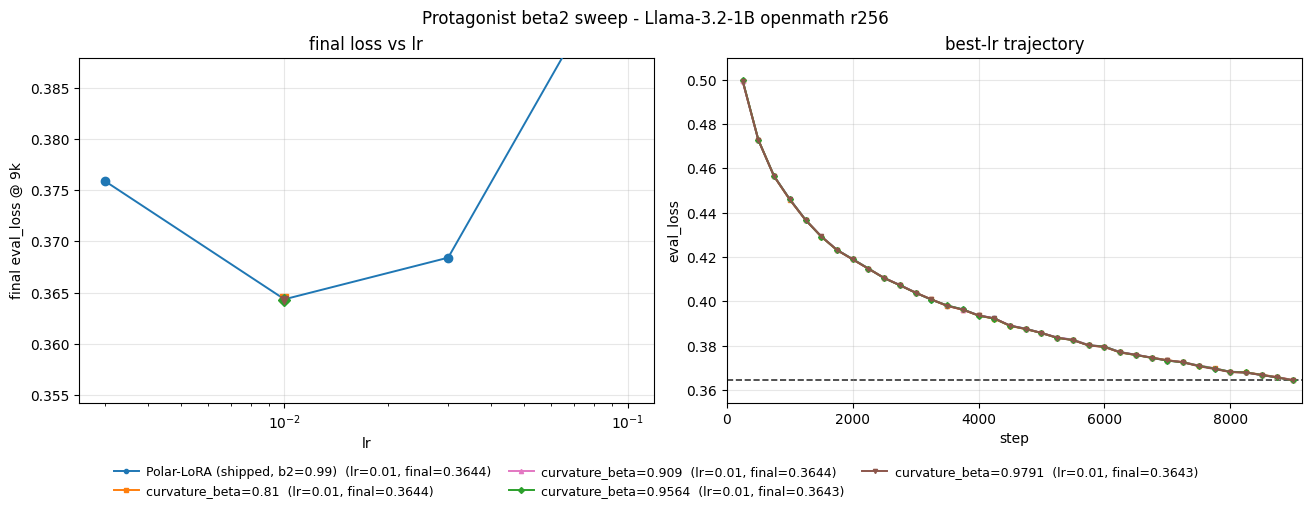

,variant,best_lr,final,delta,delta_sigma
0,"Polar-LoRA (shipped, b2=0.99)",0.01,0.364357,NaN,NaN
1,curvature_beta=0.81,0.01,0.364447,0.000091,0.053349
2,curvature_beta=0.909,0.01,0.364445,0.000089,0.052132
3,curvature_beta=0.9564,0.01,0.364279,-0.000077,-0.045367
4,curvature_beta=0.9791,0.01,0.364299,-0.000058,-0.033849


In [30]:
P.beta2_panel(256)


### Figure 28. Live tracking — AdamW $\beta_2$ control

AdamW on the same $\beta_2$ grid at its tuned $\eta=10^{-4}$. All four pre-existing
AdamW runs at this setting use $\beta_2=0.999$, so there was no coverage before.

**Plotted:** eval loss vs step per $\beta_2$, and per-cell progress.
**Why:** the control for Figure 20. If $\beta_2$ moves neither optimizer, the
workload's gradient shapes are simply stable; if it moves AdamW but not the
protagonist, the protagonist's max-normalized diagonal metric is insensitive to
the window.

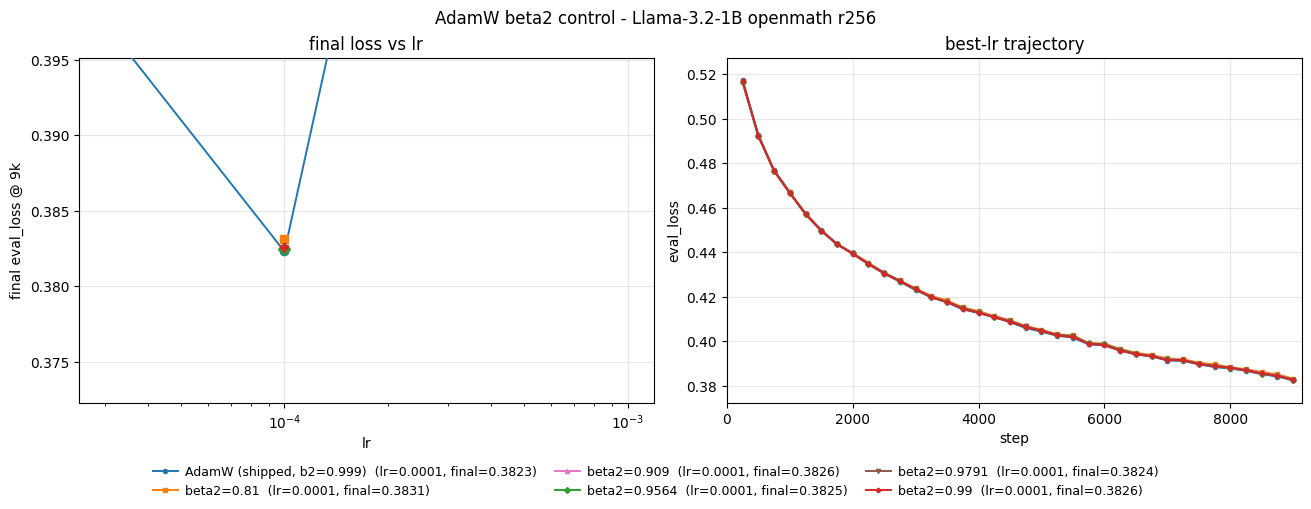

,variant,best_lr,final,delta,delta_sigma
0,"AdamW (shipped, b2=0.999)",0.0001,0.382301,None,None
1,beta2=0.81,0.0001,0.383098,None,None
2,beta2=0.909,0.0001,0.382621,None,None
3,beta2=0.9564,0.0001,0.382463,None,None
4,beta2=0.9791,0.0001,0.382440,None,None
5,beta2=0.99,0.0001,0.382597,None,None


In [31]:
P.adamw_beta2_panel(256)


### Figure 29. Magnitude rule — naive $\rho=\eta$ vs the PoLoRA rule

$\rho=\eta$ flat instead of $\rho=\eta/(\|A\|_2+\|B\|_2)$ (`optim.py:1960-1961`), so each
factor update is normalised to spectral norm $\eta$. The $\sigma_{\max}$ rescale is
kept, so this swaps the magnitude *rule* rather than removing magnitude control.

**Plotted:** eval loss vs step per learning rate, and per-cell progress.
**Why:** $\eta$ means something different here — the protagonist divides by
$\|A\|_2+\|B\|_2$, which is $O(1\text{–}10)$ and grows — so the grid is shifted down
and the swept axis is the learning rate rather than $\beta_2$.

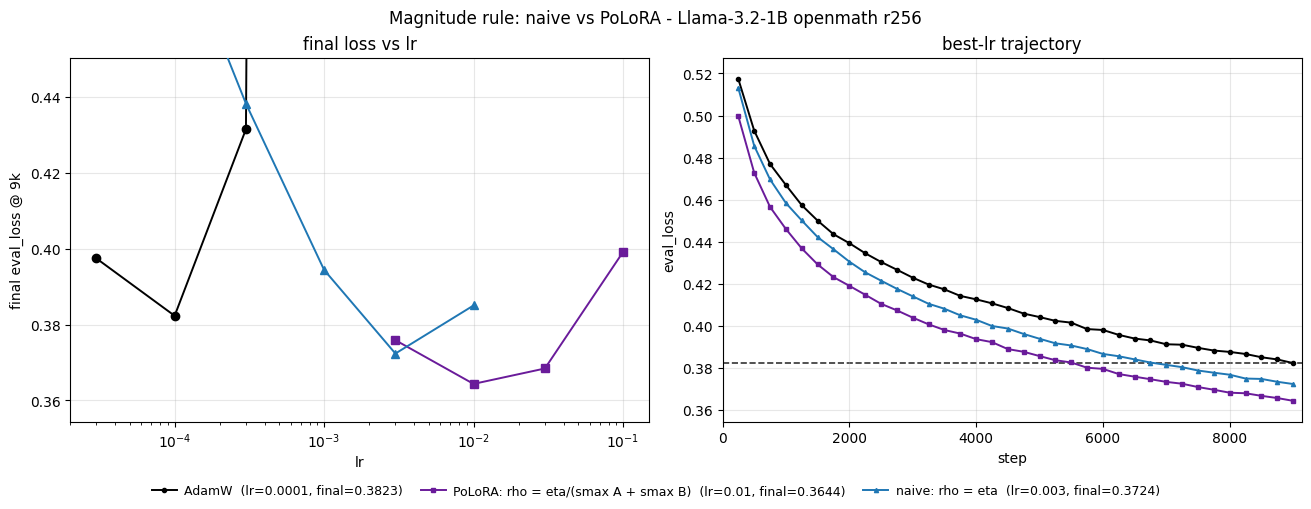

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,0.017944,10.555354
1,PoLoRA: rho = eta/(smax A + smax B),0.0100,0.364357,NaN,NaN
2,naive: rho = eta,0.0030,0.372352,0.007995,4.702933


In [32]:
P.magnitude_rule_panel(256)
